In [165]:
# %matplotlib macosx
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from optim import SSBFGS, SSBroyden

In [166]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        return self.net(X)

Solve the problem for the Poisson equation in a ring in the plane,
$$
\begin{cases}
\Delta u = 1 & \quad 4 < x^2 + y^2 < 9, \\
u = \frac{x}{x^2 + y^2} & \quad x^2 + y^2 = 4 \\
x \frac{\partial u}{\partial x} + y \frac{\partial u}{\partial y} = 0 & \quad x^2 + y^2 = 9
\end{cases}
$$

With exact solution: $u(x, y) = \frac{x}{13} + \frac{9x}{13(x^2 + y^2)} + \frac{x^2 + y^2}{4} - \frac{9}{4}\ln(x^2+y^2) + \frac{9}{2}\ln{2} - 1$.

In [167]:
torch.manual_seed(42)
np.random.seed(42)

In [168]:
# --- Collocation points ---
N_f = 200
r_f = torch.rand(N_f, 1) + 2
theta_f = (torch.rand(N_f, 1) - 0.5) * 2 * math.pi
x_f = (r_f * torch.cos(theta_f)).requires_grad_(True)
y_f = (r_f * torch.sin(theta_f)).requires_grad_(True)

f = (-2 * math.pi**2 * torch.sin(math.pi * x_f) * torch.sin(math.pi * y_f)).detach()

# --- Boundary points r=2 ---
N_b = 100
theta_bc = 2 * math.pi * torch.rand(N_b, 1) - math.pi  # so it is in range (-pi, pi)
x_bc = 2 * torch.cos(theta_bc)
y_bc = 2 * torch.sin(theta_bc)
u_bc = (x_bc / 4).detach()  # u = x/(x^2+y^2) = x/4 on r=2

# --- Boundary points r=3 ---
theta_bc2 = 2 * math.pi * torch.rand(N_b, 1) - math.pi
x_bc2 = (3 * torch.cos(theta_bc2)).requires_grad_(True)
y_bc2 = (3 * torch.sin(theta_bc2)).requires_grad_(True)

# --- Exact solution ---
u_exact_train = (x_f/13.0 + 9.0 * x_f/13.0 / (x_f ** 2 + y_f ** 2) + (x_f ** 2 + y_f ** 2) / 4.0 - 9.0 / 4.0 * torch.log(x_f ** 2 + y_f ** 2) + 9/2 * math.log(2) - 1).detach()
l1_error = {'adam':[], 'std':[], 'sqrt':[], 'log':[], 'ssbfgs':[], 'ssbroyden':[]}
l2_error = {'adam':[], 'std':[], 'sqrt':[], 'log':[], 'ssbfgs':[], 'ssbroyden':[]}
l2_relative_error = {'adam':[], 'std':[], 'sqrt':[], 'log':[], 'ssbfgs':[], 'ssbroyden':[]}
mse = {'adam':[], 'std':[], 'sqrt':[], 'log':[], 'ssbfgs':[], 'ssbroyden':[]}
l_inf_error = {'adam':[], 'std':[], 'sqrt':[], 'log':[], 'ssbfgs':[], 'ssbroyden':[]}

In [169]:
def compute_loss(net):
    # Wipe the input gradients inside the closure!
    if x_f.grad is not None: x_f.grad.zero_()
    if y_f.grad is not None: y_f.grad.zero_()

    # PDE residual
    u_f = net(x_f, y_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_y = torch.autograd.grad(u_f.sum(), y_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]

    residual = u_xx + u_yy - 1.0
    loss_pde = torch.mean(residual**2)

    # Boundary loss r = 2
    u_bc_pred = net(x_bc, y_bc)
    loss_bc = torch.mean((u_bc - u_bc_pred) ** 2)

    # Boundary loss r = 3
    u_bc2_pred = net(x_bc2, y_bc2)
    u_bc2_x = torch.autograd.grad(u_bc2_pred.sum(), x_bc2, create_graph=True)[0]
    u_bc2_y = torch.autograd.grad(u_bc2_pred.sum(), y_bc2, create_graph=True)[0]
    normal_dot_grad = x_bc2 * u_bc2_x + y_bc2 * u_bc2_y
    loss_bc2 = torch.mean(normal_dot_grad ** 2)

    return loss_pde + loss_bc + loss_bc2

def record_metrics(net, name):
    # Disable gradients just for metric calculation to save memory/time
    with torch.no_grad():
        u_f = net(x_f, y_f)
        diff = u_f - u_exact_train

        l1_error[name].append(torch.mean(torch.abs(diff)).item())
        l2_error[name].append(torch.sqrt(torch.mean(diff ** 2)).item())
        l2_relative_error[name].append((torch.norm(diff) / torch.norm(u_exact_train)).item())
        mse[name].append(torch.mean(diff ** 2).item())
        l_inf_error[name].append(torch.max(torch.abs(diff)).item())

        plateau_mse = False
        if len(mse[name]) > 100:
            window = mse[name][-100:]  # or -200:
            rel_spread = (max(window) - min(window)) / (min(window) + 1e-12)
            plateau_mse = rel_spread < 1e-4

        return plateau_mse

In [170]:
# --- Initialize the network ---
layers = [2, 40, 40, 40, 1]
model = Net(layers)
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)

# --- Stage 1: Adam Optimizer (Initialization) ---
print("Stage 1: Pre-training with Adam...")
start = time.time()
for epoch in range(2000):
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(model, 'adam')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

adam_time = time.time() - start

Stage 1: Pre-training with Adam...
Epoch 0, Loss: 1.124928e+00
Epoch 500, Loss: 2.555575e-03
Epoch 1000, Loss: 9.867336e-04
Epoch 1500, Loss: 4.355467e-04


In [171]:
model_std_lbfgs = copy.deepcopy(model) # Experiment 2
l1_error["std"] = l1_error["adam"][:]
l2_error["std"] = l2_error["adam"][:]
l2_relative_error["std"] = l2_relative_error["adam"][:]
mse["std"] = mse["adam"][:]
l_inf_error["std"] = l_inf_error["adam"][:]

model_sqrt_lbfgs = copy.deepcopy(model) # Experiment 3
l1_error["sqrt"] = l1_error["adam"][:]
l2_error["sqrt"] = l2_error["adam"][:]
l2_relative_error["sqrt"] = l2_relative_error["adam"][:]
mse["sqrt"] = mse["adam"][:]
l_inf_error["sqrt"] = l_inf_error["adam"][:]

model_log_lbfgs = copy.deepcopy(model) # Experiment 4
l1_error["log"] = l1_error["adam"][:]
l2_error["log"] = l2_error["adam"][:]
l2_relative_error["log"] = l2_relative_error["adam"][:]
mse["log"] = mse["adam"][:]
l_inf_error["log"] = l_inf_error["adam"][:]

model_ssbfgs = copy.deepcopy(model) # Experiment 5
l1_error["ssbfgs"] = l1_error["adam"][:]
l2_error["ssbfgs"] = l2_error["adam"][:]
l2_relative_error["ssbfgs"] = l2_relative_error["adam"][:]
mse["ssbfgs"] = mse["adam"][:]
l_inf_error["ssbfgs"] = l_inf_error["adam"][:]

model_ssbroyden = copy.deepcopy(model) # Experiment 6
l1_error["ssbroyden"] = l1_error["adam"][:]
l2_error["ssbroyden"] = l2_error["adam"][:]
l2_relative_error["ssbroyden"] = l2_relative_error["adam"][:]
mse["ssbroyden"] = mse["adam"][:]
l_inf_error["ssbroyden"] = l_inf_error["adam"][:]

In [172]:
# --- EXPERIMENT 1: Continue with Adam (No LBFGS) ---
print("Exp 1: Continuing Adam...")
start = time.time()
for epoch in range(2000, 5000):
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(model, 'adam')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch},  Loss: {loss.item():.6e}")

print(f"Total time Adam: {adam_time + time.time() - start:.2f} seconds")

Exp 1: Continuing Adam...
Epoch 2000,  Loss: 5.520280e-04
Epoch 2500,  Loss: 1.408451e-04
Epoch 3000,  Loss: 9.655864e-05
Epoch 3500,  Loss: 1.080268e-03
Epoch 4000,  Loss: 8.209657e-05
Epoch 4500,  Loss: 9.980323e-05
Total time Adam: 16.72 seconds


In [173]:
# --- EXPERIMENT 2: Standard LBFGS (Minimize MSE) ---
print("Exp 2: Standard LBFGS (MSE)...")
opt_std = optim.LBFGS(
    model_std_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

lbfgs_epochs = 2000

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_std():
        opt_std.zero_grad()
        loss = compute_loss(model_std_lbfgs) # Standard Loss
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_std.step(closure_std)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_std_lbfgs, 'std')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_std().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

lbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + LBFGS): {lbfgs_time:.2f} seconds")

Exp 2: Standard LBFGS (MSE)...
L-BFGS Epoch 0, Loss: 5.520280e-04
L-BFGS Epoch 500, Loss: 7.220055e-06
L-BFGS Epoch 1000, Loss: 2.002792e-06
L-BFGS Epoch 1500, Loss: 1.276616e-06
Total time (Adam + LBFGS): 19.61 seconds


In [174]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize Sqrt(MSE)) ---
print("Exp 3: Modified LBFGS (J_1/2)...")
opt_sqrt = optim.LBFGS(
    model_sqrt_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_sqrt():
        opt_sqrt.zero_grad()
        loss_mse = compute_loss(model_sqrt_lbfgs)
        loss_sqrt = torch.sqrt(loss_mse)
        loss_sqrt.backward()
        return loss_sqrt

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_sqrt.step(closure_sqrt)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_sqrt_lbfgs, 'sqrt')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_sqrt().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.pow(loss_val.item(), 2):.6e}")

sqrt_time = adam_time + time.time() - start
print(f"Total time (Adam + sqrt LBFGS): {sqrt_time:.2f} seconds")

Exp 3: Modified LBFGS (J_1/2)...
L-BFGS Epoch 0, Loss: 5.520280e-04
L-BFGS Epoch 500, Loss: 7.160086e-06
L-BFGS Epoch 1000, Loss: 1.780570e-06
L-BFGS Epoch 1500, Loss: 1.047753e-06
Total time (Adam + sqrt LBFGS): 21.90 seconds


In [175]:
# --- EXPERIMENT 4: Modified LBFGS (Minimize log(MSE)) ---
print("Exp 4: Modified LBFGS (log(J))...")
opt_log = optim.LBFGS(
    model_log_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_log():
        opt_log.zero_grad()
        loss_mse = compute_loss(model_log_lbfgs)
        loss_log = torch.log(loss_mse)
        loss_log.backward()
        return loss_log

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_log.step(closure_log)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_log_lbfgs, 'log')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_log().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.exp(loss_val.item()):.6e}")

log_time = adam_time + time.time() - start
print(f"Total time (Adam + log LBFGS): {log_time:.2f} seconds")

Exp 4: Modified LBFGS (log(J))...
L-BFGS Epoch 0, Loss: 5.520281e-04
L-BFGS Epoch 500, Loss: 6.339789e-06
L-BFGS Epoch 1000, Loss: 1.597009e-06
L-BFGS Epoch 1500, Loss: 1.048291e-06
Total time (Adam + log LBFGS): 22.46 seconds


In [176]:
# --- EXPERIMENT 5: Modified BFGS (SSBFGS) ---
print("Exp 5: SSBFGS...")
opt_ssbfgs = SSBFGS(
    model_ssbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbfgs():
        opt_ssbfgs.zero_grad()
        loss = compute_loss(model_ssbfgs)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_ssbfgs.step(closure_ssbfgs)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_ssbfgs, 'ssbfgs')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbfgs().item()
        print(f"SSBFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBFGS): {ssbfgs_time:.2f} seconds")

Exp 5: SSBFGS...
SSBFGS Epoch 0, Loss: 2.990894e-04
SSBFGS Epoch 500, Loss: 3.303544e-07
SSBFGS Epoch 1000, Loss: 2.147299e-08
Total time (Adam + SSBFGS): 55.35 seconds


In [177]:
# --- EXPERIMENT 6: Modified Broyden (SSBroyden) ---
print("Exp 6: SSBroyden...")
opt_ssbroyden = SSBroyden(
    model_ssbroyden.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbroyden():
        opt_ssbroyden.zero_grad()
        loss = compute_loss(model_ssbroyden)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_ssbroyden.step(closure_ssbroyden)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_ssbroyden, 'ssbroyden')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbroyden().item()
        print(f"SSBroyden Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbroyden_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBroyden): {ssbroyden_time:.2f} seconds")

Exp 6: SSBroyden...
SSBroyden Epoch 0, Loss: 2.990894e-04
SSBroyden Epoch 500, Loss: 2.190683e-07
SSBroyden Epoch 1000, Loss: 7.548922e-09
Total time (Adam + SSBroyden): 57.76 seconds


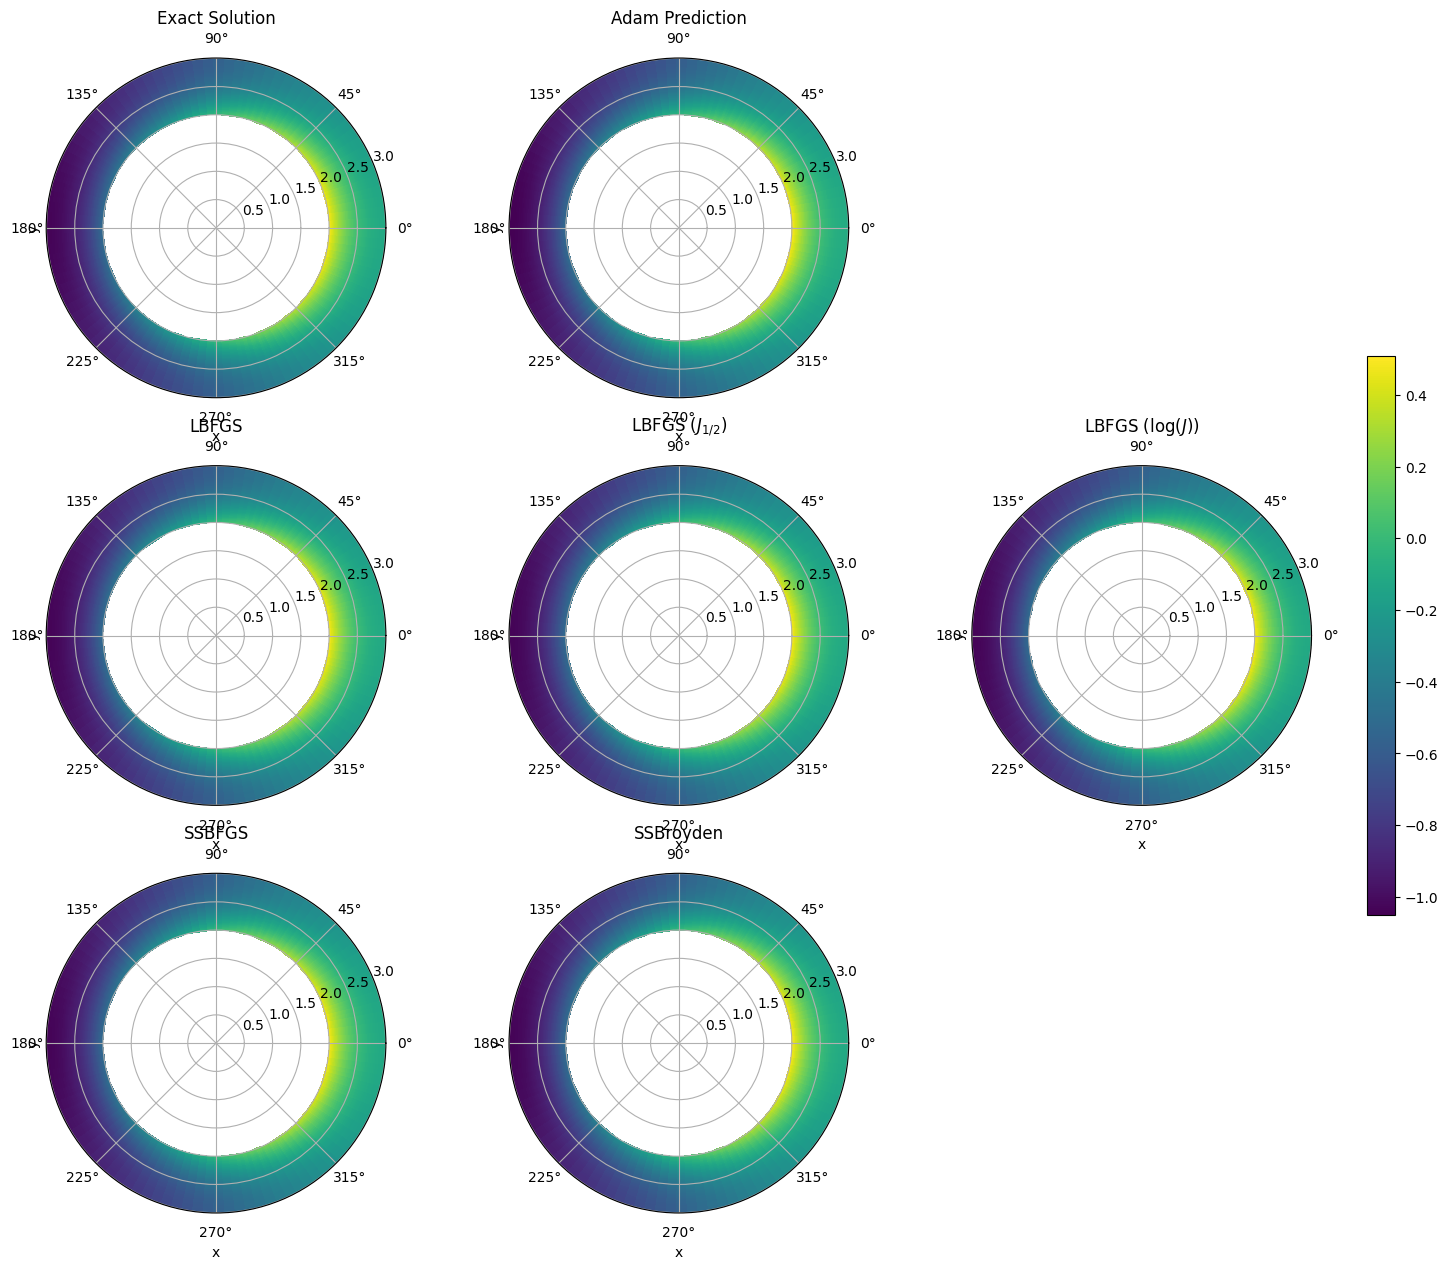

In [196]:
# --- Evaluation ---
r = np.linspace(2, 3, 100)
theta = np.linspace(-np.pi, np.pi, 100)
R, T = np.meshgrid(r, theta)

# Convert to torch for prediction
R_flat = torch.tensor(R.flatten(), dtype=torch.float32).reshape(-1, 1)
T_flat = torch.tensor(T.flatten(), dtype=torch.float32).reshape(-1, 1)

X_flat = R_flat * torch.cos(T_flat)
Y_flat = R_flat * torch.sin(T_flat)

with torch.no_grad():
    u_pred = model(X_flat, Y_flat).reshape(100,100)
    u_pred_std = model_std_lbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_sqrt = model_sqrt_lbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_log = model_log_lbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_ssbfgs = model_ssbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_ssbroyden = model_ssbroyden(X_flat, Y_flat).reshape(100, 100)
    u_exact_vis = (1.0/13.0 * X_flat + 9.0 * X_flat/13.0 / (X_flat ** 2 + Y_flat ** 2) + (X_flat ** 2 + Y_flat ** 2) / 4.0 - 9.0 / 4.0 * torch.log(X_flat ** 2 + Y_flat ** 2) + 9/2 * math.log(2) - 1).reshape(100, 100)



all_data = [u_exact_vis, u_pred, u_pred_std, u_pred_sqrt, u_pred_log, u_pred_ssbfgs, u_pred_ssbroyden]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

fig = plt.figure(figsize=(18,15))

# Exact solution
plt.subplot(3,3,1, projection='polar')
im = plt.pcolormesh(T, R, u_exact_vis, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Exact Solution')
plt.xlabel('x')
plt.ylabel('y')

# PINN prediction
plt.subplot(3,3,2, projection='polar')
plt.pcolormesh(T, R, u_pred, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Adam Prediction')
plt.xlabel('x')
plt.ylabel('y')

# Standard LBFGS prediction
plt.subplot(3,3,4, projection='polar')
plt.pcolormesh(T, R, u_pred_std, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('LBFGS')
plt.xlabel('x')
plt.ylabel('y')

# Sqrt LBFGS prediction
plt.subplot(3,3,5, projection='polar')
plt.pcolormesh(T, R, u_pred_sqrt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($J_{1/2}$)')
plt.xlabel('x')
plt.ylabel('y')

# Log LBFGS prediction
plt.subplot(3,3,6, projection='polar')
plt.pcolormesh(T, R, u_pred_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($\log(J)$)')
plt.xlabel('x')
plt.ylabel('y')

# Sqrt SSBFGS prediction
plt.subplot(3,3,7, projection='polar')
plt.pcolormesh(T, R, u_pred_ssbfgs, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

# Log SSBroyden prediction
plt.subplot(3,3,8, projection='polar')
plt.pcolormesh(T, R, u_pred_ssbroyden, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

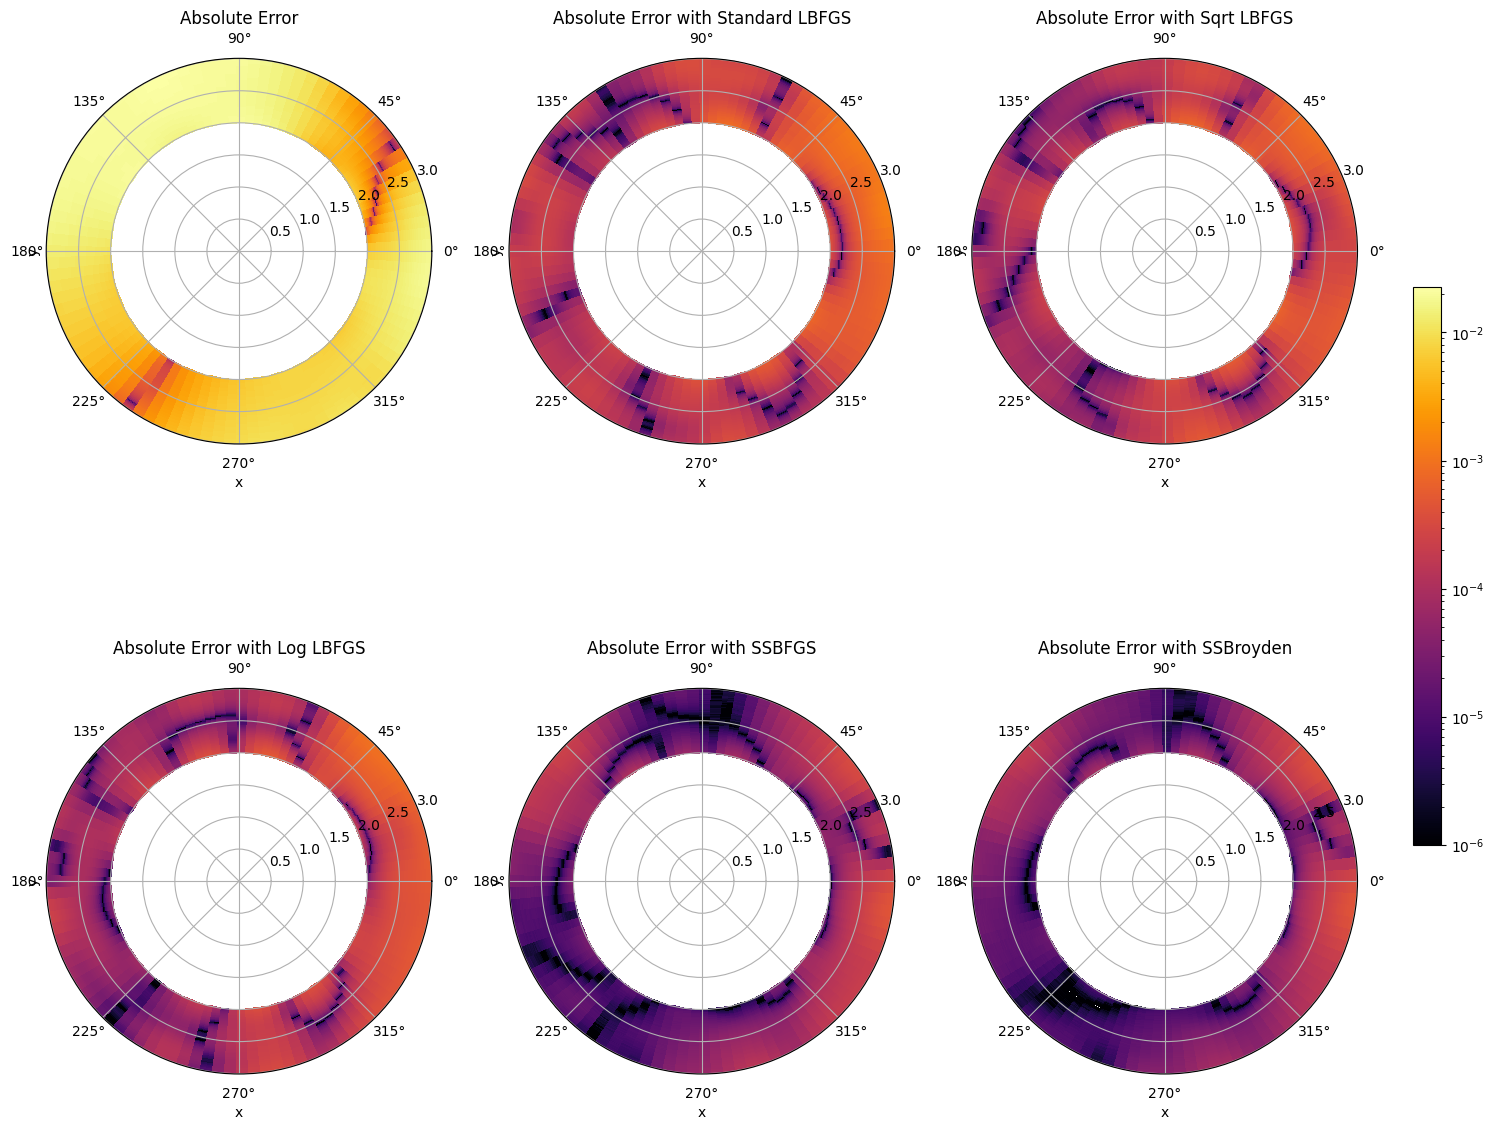

In [197]:
err_adam = torch.abs(u_pred - u_exact_vis)
err_std  = torch.abs(u_pred_std - u_exact_vis)
err_sqrt = torch.abs(u_pred_sqrt - u_exact_vis)
err_log  = torch.abs(u_pred_log - u_exact_vis)
err_ssbfgs = torch.abs(u_pred_ssbfgs - u_exact_vis)
err_ssbroyden  = torch.abs(u_pred_ssbroyden - u_exact_vis)


all_errors = [err_adam, err_std, err_sqrt, err_log, err_ssbfgs, err_ssbroyden]
vmin_log = 1e-6
vmax = max(e.max() for e in all_errors)

fig = plt.figure(figsize=(18,15))

plt.subplot(2,3,1, projection='polar')
im = plt.pcolormesh(T, R, err_adam, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2,3,2, projection='polar')
plt.pcolormesh(T, R, err_std, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Standard LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2,3,3, projection='polar')
plt.pcolormesh(T, R, err_sqrt, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Sqrt LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2,3,4, projection='polar')
plt.pcolormesh(T, R, err_log, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Log LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2,3,5, projection='polar')
plt.pcolormesh(T, R, err_ssbfgs, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(2,3,6, projection='polar')
plt.pcolormesh(T, R, err_ssbroyden, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

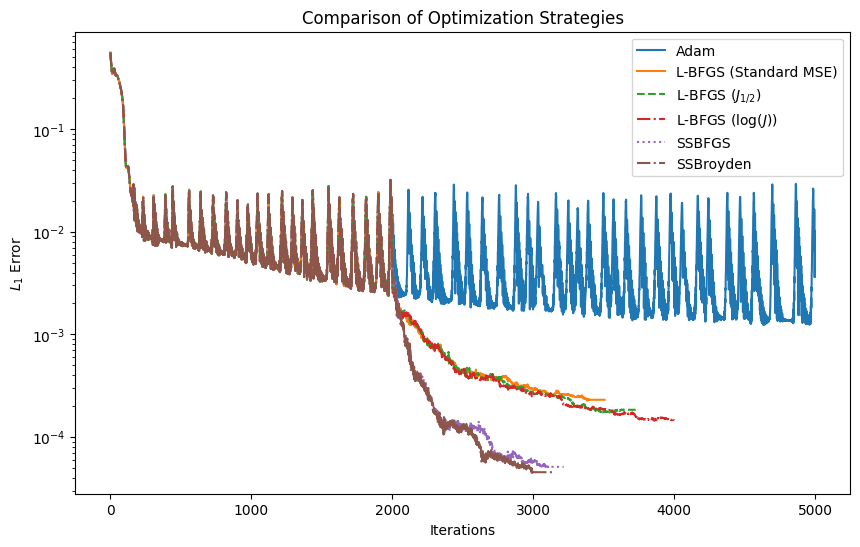

In [198]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l1_error["adam"], label='Adam') # Exp 1: More Adam
plt.semilogy(l1_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l1_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l1_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l1_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l1_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'$L_1$ Error')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

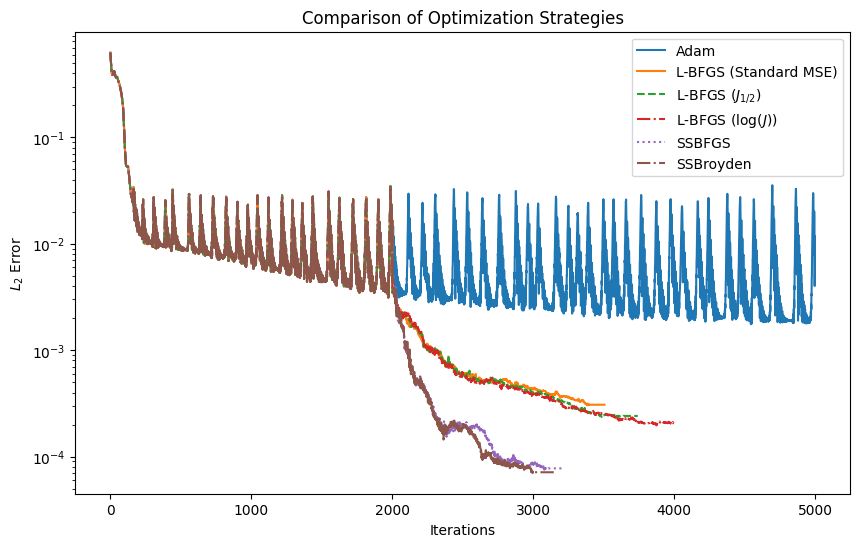

In [199]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l2_error["adam"], label='Adam') # Exp 1: More Adam
plt.semilogy(l2_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l2_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l2_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel('$L_2$ Error')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

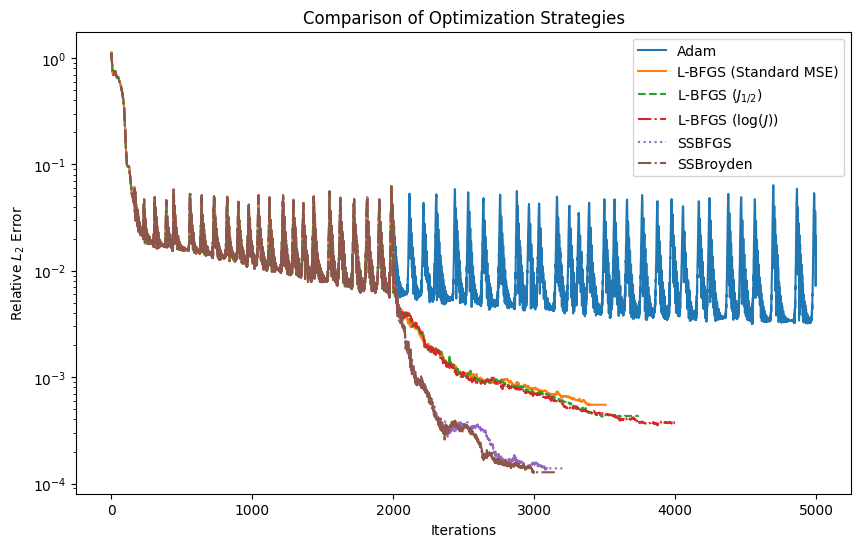

In [200]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l2_relative_error["adam"], label='Adam') # Exp 1: More Adam
plt.semilogy(l2_relative_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_relative_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_relative_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l2_relative_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l2_relative_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'Relative $L_2$ Error')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

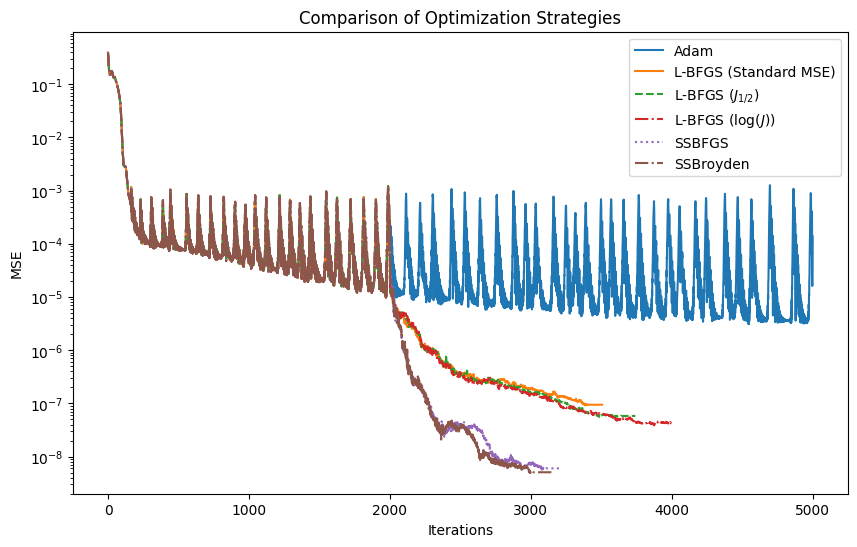

In [201]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(mse["adam"], label='Adam') # Exp 1: More Adam
plt.semilogy(mse["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(mse["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(mse["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(mse["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(mse["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

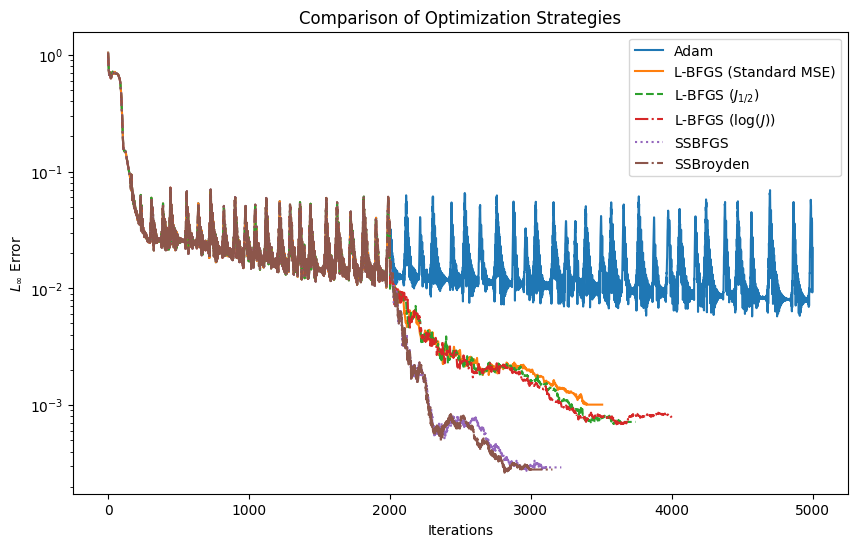

In [202]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l_inf_error["adam"], label='Adam') # Exp 1: More Adam
plt.semilogy(l_inf_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l_inf_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l_inf_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l_inf_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l_inf_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'$L_{\infty}$ Error')
plt.title('Comparison of Optimization Strategies')
plt.legend()
plt.show()

In [203]:
mse_adam = torch.mean(err_adam ** 2)
mse_std = torch.mean(err_std ** 2)
mse_sqrt = torch.mean(err_sqrt ** 2)
mse_log = torch.mean(err_log ** 2)
mse_ssbfgs = torch.mean(err_ssbfgs ** 2)
mse_ssbroyden = torch.mean(err_ssbroyden ** 2)


print("MSE:")
print(f"Adam: {mse_adam:.6e}")
print(f"LBFGS: {mse_std:.6e}")
print(f"LBFGS J_1/2: {mse_sqrt:.6e}")
print(f"LBFGS log(J): {mse_log:.6e}")
print(f"SSBFGS: {mse_ssbfgs:.6e}")
print(f"SSBroyden: {mse_ssbroyden:.6e}")

MSE:
Adam: 1.446322e-04
LBFGS: 1.336154e-07
LBFGS J_1/2: 6.446361e-08
LBFGS log(J): 5.676870e-08
SSBFGS: 8.966952e-09
SSBroyden: 8.065604e-09
